In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler,MaxAbsScaler,RobustScaler
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,accuracy_score

In [4]:
df=pd.read_csv(r"C:\Users\tatak\Downloads\candy-data.csv")
df

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282
81,Warheads,0,1,0,0,0,0,1,0,0,0.093,0.116,39.011898
82,WelchÕs Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519
83,WertherÕs Original Caramel,0,0,1,0,0,0,1,0,0,0.186,0.267,41.904308


In [5]:
df.shape

(85, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   competitorname    85 non-null     object 
 1   chocolate         85 non-null     int64  
 2   fruity            85 non-null     int64  
 3   caramel           85 non-null     int64  
 4   peanutyalmondy    85 non-null     int64  
 5   nougat            85 non-null     int64  
 6   crispedricewafer  85 non-null     int64  
 7   hard              85 non-null     int64  
 8   bar               85 non-null     int64  
 9   pluribus          85 non-null     int64  
 10  sugarpercent      85 non-null     float64
 11  pricepercent      85 non-null     float64
 12  winpercent        85 non-null     float64
dtypes: float64(3), int64(9), object(1)
memory usage: 8.8+ KB


In [7]:
df.describe()

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,0.435294,0.447059,0.164706,0.164706,0.082353,0.082353,0.176471,0.247059,0.517647,0.478647,0.468882,50.316764
std,0.498738,0.500140,0.373116,0.373116,0.276533,0.276533,0.383482,0.433861,0.502654,0.282778,0.285740,14.714357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011000,0.011000,22.445341
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220000,0.255000,39.141056
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.465000,0.465000,47.829754
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.732000,0.651000,59.863998
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988000,0.976000,84.180290


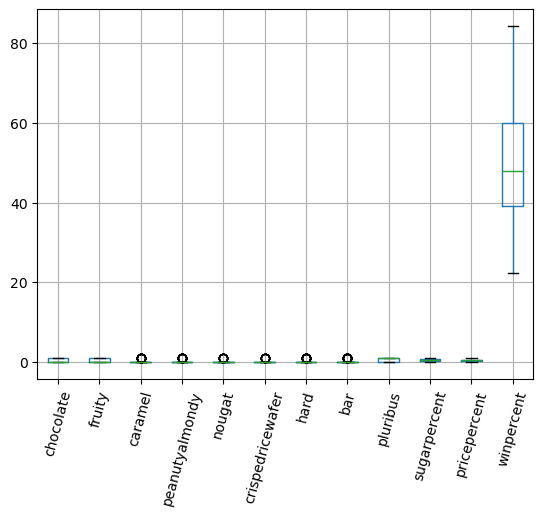

In [8]:
df.boxplot()
plt.xticks(rotation=75)
plt.show()

In [9]:
df1=df.select_dtypes(include='number')

In [10]:
for i in df1:
    Q1=df[i].quantile(.25)
    Q3=df[i].quantile(.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    df[i]=df[i].clip(lower_limit,upper_limit)

In [11]:
df

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,0,0,0,0,0,0,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,0,0,0,0,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282
81,Warheads,0,1,0,0,0,0,0,0,0,0.093,0.116,39.011898
82,WelchÕs Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519
83,WertherÕs Original Caramel,0,0,0,0,0,0,0,0,0,0.186,0.267,41.904308


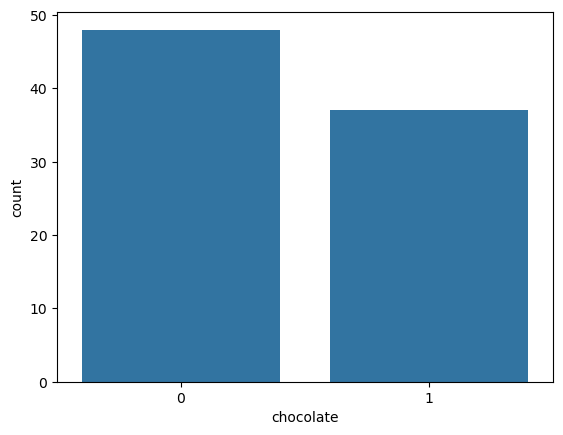

In [12]:
sns.countplot(x="chocolate",data=df)
plt.show()

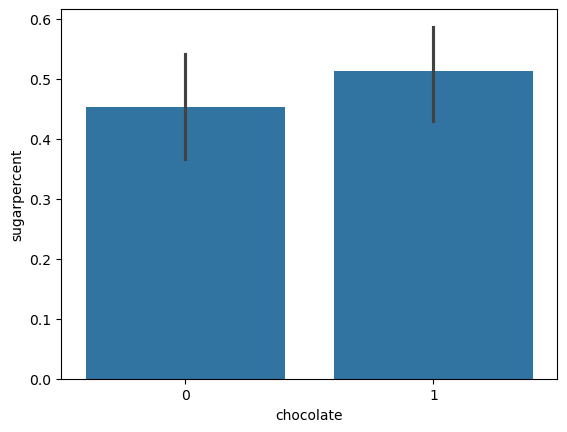

In [13]:
sns.barplot(x="chocolate",y="sugarpercent",data=df)
plt.show()

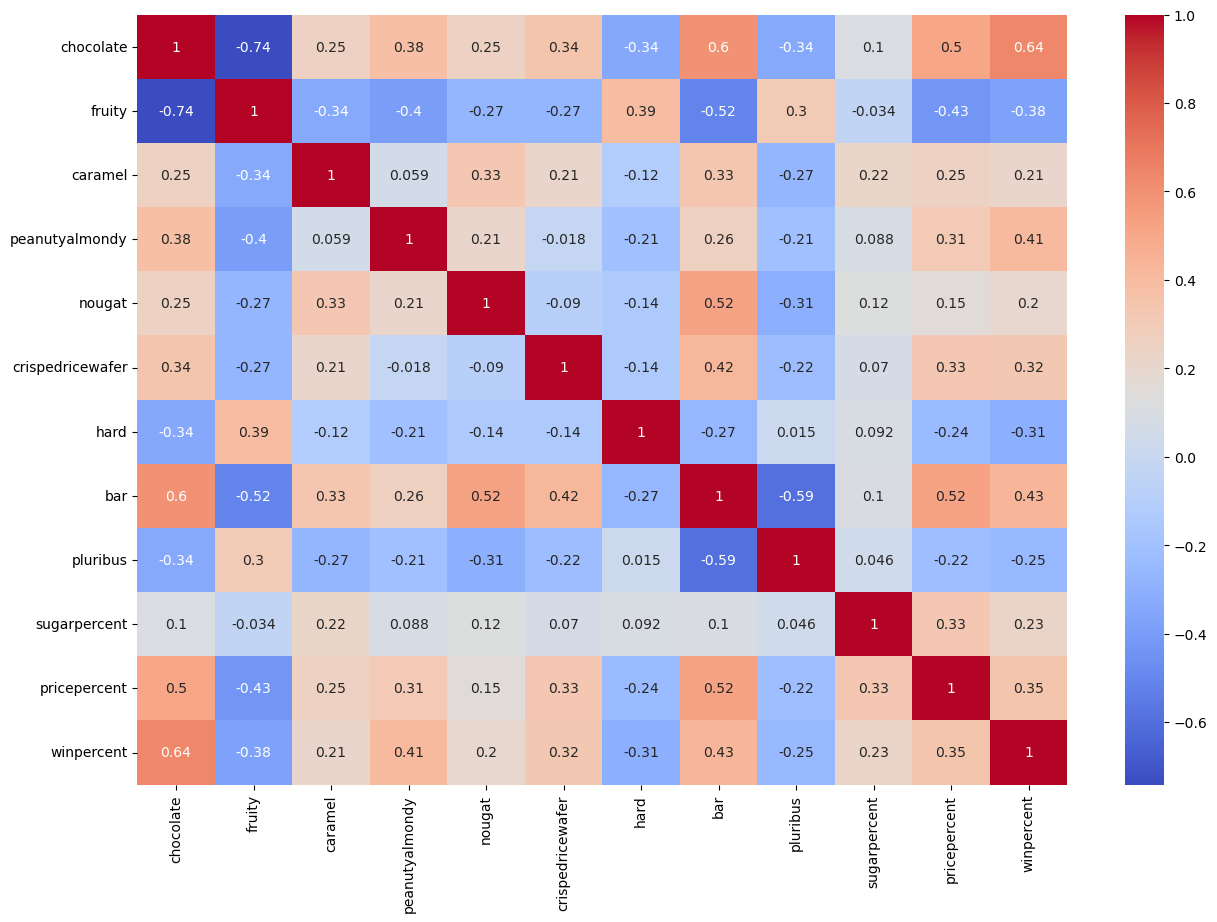

In [14]:
plt.figure(figsize=(15,10))
df2=df1.corr()
sns.heatmap(df2,annot=True,cmap="coolwarm")
plt.show()

In [15]:
df

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,0,0,0,0,0,0,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,0,0,0,0,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282
81,Warheads,0,1,0,0,0,0,0,0,0,0.093,0.116,39.011898
82,WelchÕs Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519
83,WertherÕs Original Caramel,0,0,0,0,0,0,0,0,0,0.186,0.267,41.904308


In [16]:
df.columns

Index(['competitorname', 'chocolate', 'fruity', 'caramel', 'peanutyalmondy',
       'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
       'pricepercent', 'winpercent'],
      dtype='object')

In [17]:
le=LabelEncoder()
df["competitorname"]=le.fit_transform(df["competitorname"])

In [18]:
scaler=StandardScaler()
cols=['competitorname','chocolate', 'fruity', 'caramel', 'peanutyalmondy',
       'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
       'pricepercent']
sca=scaler.fit_transform(df[cols])
sca

array([[-1.71179221,  1.13898959, -0.8991722 , ..., -1.03593954,
         0.90126052,  1.37691389],
       [-1.67103525,  1.13898959, -0.8991722 , ..., -1.03593954,
         0.44592195,  0.1482734 ],
       [ 0.08151391, -0.87797115, -0.8991722 , ..., -1.03593954,
        -1.66357582, -1.24230805],
       ...,
       [ 1.63027829, -0.87797115,  1.11213403, ...,  0.9653073 ,
        -0.58926159, -0.54877755],
       [ 1.67103525, -0.87797115, -0.8991722 , ..., -1.03593954,
        -1.04104272, -0.71071869],
       [ 1.71179221,  1.13898959, -0.8991722 , ...,  0.9653073 ,
         1.39928696,  1.33466831]], shape=(85, 12))

In [19]:
df[['competitorname','chocolate', 'fruity', 'caramel', 'peanutyalmondy','nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
    'pricepercent']]=pd.DataFrame(sca,columns=cols)

In [20]:
x=df.drop(["winpercent"],axis=1)
x

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent
0,-1.711792,1.138990,-0.899172,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,0.901261,1.376914
1,-1.671035,1.138990,-0.899172,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,0.445922,0.148273
2,0.081514,-0.877971,-0.899172,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,-1.663576,-1.242308
3,0.122271,-0.877971,-0.899172,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,-1.663576,0.148273
4,-1.630278,-0.877971,1.112134,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,1.520236,0.148273
...,...,...,...,...,...,...,...,...,...,...,...,...
80,1.548764,-0.877971,1.112134,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,-0.920093,-1.242308
81,1.589521,-0.877971,1.112134,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,-1.371875,-1.242308
82,1.630278,-0.877971,1.112134,0.0,0.0,0.0,0.0,0.0,0.0,0.965307,-0.589262,-0.548778
83,1.671035,-0.877971,-0.899172,0.0,0.0,0.0,0.0,0.0,0.0,-1.035940,-1.041043,-0.710719


In [21]:
y=df["winpercent"]
y

0     66.971725
1     67.602936
2     32.261086
3     46.116505
4     52.341465
        ...    
80    45.466282
81    39.011898
82    44.375519
83    41.904308
84    49.524113
Name: winpercent, Length: 85, dtype: float64

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [25]:
y_pred=model.predict(x_test)
y_pred

array([40.65140849, 63.24421295, 38.52955951, 51.79154393, 35.15596791,
       40.87056671, 61.91876506, 39.87368946, 49.19526943, 37.50013061,
       60.48143324, 58.25353079, 54.49122041, 43.99706035, 50.04195145,
       67.96012755, 59.95694074])

In [26]:
r2=r2_score(y_test,y_pred)
r2

0.09996469037415545

In [27]:
model_1=RandomForestRegressor()
model_1.fit(x_train,y_train)

RandomForestRegressor()

In [28]:
y_pred=model_1.predict(x_test)
y_pred

array([47.07258085, 60.75005309, 45.04322997, 54.02633837, 38.2303614 ,
       46.29184911, 63.01065787, 45.99089944, 37.13548073, 48.08757747,
       57.50335078, 71.80509419, 63.67494579, 44.50342664, 33.38355707,
       74.00591277, 66.53342775])

In [29]:
r2=r2_score(y_test,y_pred)
r2

0.3614093988161827

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [31]:
model_2=DecisionTreeRegressor(criterion="absolute_error",random_state=42)
model_2.fit(x_train,y_train)

DecisionTreeRegressor(criterion='absolute_error', random_state=42)

In [32]:
y_pred=model_2.predict(x_test)
y_pred

array([45.995827, 50.347546, 45.995827, 34.722   , 41.389557, 39.011898,
       67.602936, 51.41243 , 36.017628, 52.825947, 47.829754, 73.099556,
       73.43499 , 45.466282, 22.445341, 71.46505 , 60.800701])

In [33]:
r2=r2_score(y_test,y_pred)
r2

-0.04281970769207821

In [34]:
arr=x.iloc[1].tolist()
print(arr)

[-1.671035249175406, 1.1389895949029987, -0.8991721961325719, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0359395405656247, 0.44592194928404055, 0.14827340370474285]


In [35]:
new_df=[[-1.671035249175406, 1.1389895949029987, -0.8991721961325719, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0359395405656247, 0.44592194928404055, 0.14827340370474285]]

In [36]:
prediction=model.predict(new_df)
prediction

array([61.63089603])

In [37]:
from sklearn.svm import SVR

In [38]:
svr_lin=SVR(kernel="linear")

In [39]:
svr_lin.fit(x_train,y_train)

SVR(kernel='linear')

In [40]:
ypred_svl=svr_lin.predict(x_test)

In [41]:
r2_sl=r2_score(y_test,ypred_svl)

In [42]:
r2_sl

0.0893870690108245

In [43]:
svr_rbf=SVR(kernel="rbf")

In [44]:
svr_rbf.fit(x_train,y_train)

SVR()

In [45]:
ypred_rbf=svr_rbf.predict(x_test)

In [46]:
r2_rbf=r2_score(y_test,ypred_rbf)

In [47]:
r2_rbf

0.04560052496969269

In [48]:
from sklearn.neighbors import KNeighborsRegressor

In [49]:
metric_k=[]
neighbors=np.arange(3,15)

In [50]:
for i in neighbors:
    knr=KNeighborsRegressor(n_neighbors=i,metric="euclidean")
    knr.fit(x_train,y_train)
    y_prediction=knr.predict(x_test)
    r2=r2_score(y_test,y_prediction)
    metric_k.append(r2)

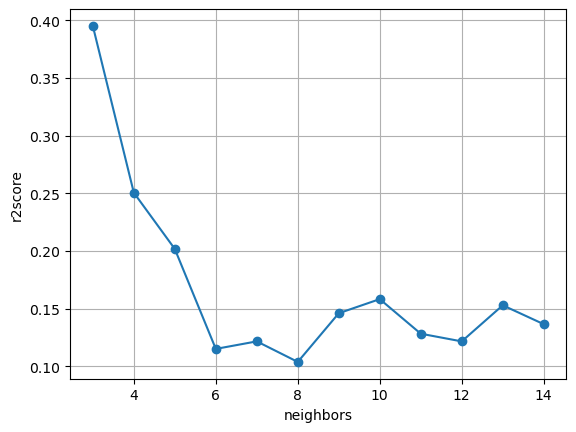

In [51]:
plt.plot(neighbors, metric_k,'o-')
plt.xlabel("neighbors")
plt.ylabel("r2score")
plt.grid()
plt.show()

In [52]:
knr=KNeighborsRegressor(n_neighbors=3,metric="euclidean")
knr.fit(x_train,y_train)
y_prediction=knr.predict(x_test)
r2=r2_score(y_test,y_prediction)
metric_k.append(r2)

In [53]:
r2

0.3952709969632052

In [54]:
from sklearn.linear_model import Lasso,Ridge

In [55]:
rid=Ridge(alpha=1.0)
rid.fit(x_train,y_train)

Ridge()

In [56]:
y_pred_r=rid.predict(x_test)

In [57]:
r2_r=r2_score(y_test,y_pred_r)
r2_r

0.09851937540220279

In [58]:
las=Lasso(alpha=0.1)
las.fit(x_train,y_train)

Lasso(alpha=0.1)

In [59]:
y_pred_l=las.predict(x_test)

In [60]:
r2_l=r2_score(y_test,y_pred_l)
r2_l

0.1065739178062326

In [61]:
#pip install XGBoost

In [62]:
from xgboost import XGBRegressor

In [63]:
xgb=XGBRegressor()
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [64]:
y_pred_x=xgb.predict(x_test)

In [65]:
r2_x=r2_score(y_test,y_pred_x)
r2_x

0.20667111503161983

In [66]:
from catboost import CatBoostRegressor

In [67]:
cb=CatBoostRegressor()
cb.fit(x_train,y_train)

Learning rate set to 0.026774
0:	learn: 14.5256455	total: 139ms	remaining: 2m 19s
1:	learn: 14.3593355	total: 140ms	remaining: 1m 9s
2:	learn: 14.2135745	total: 140ms	remaining: 46.5s
3:	learn: 14.0716863	total: 140ms	remaining: 34.9s
4:	learn: 13.9264980	total: 140ms	remaining: 27.9s
5:	learn: 13.7753847	total: 141ms	remaining: 23.3s
6:	learn: 13.6600947	total: 141ms	remaining: 20s
7:	learn: 13.5371546	total: 141ms	remaining: 17.5s
8:	learn: 13.4218647	total: 141ms	remaining: 15.6s
9:	learn: 13.2964619	total: 142ms	remaining: 14s
10:	learn: 13.1722327	total: 142ms	remaining: 12.8s
11:	learn: 13.0558573	total: 142ms	remaining: 11.7s
12:	learn: 12.9375300	total: 142ms	remaining: 10.8s
13:	learn: 12.8355761	total: 143ms	remaining: 10s
14:	learn: 12.7390965	total: 143ms	remaining: 9.38s
15:	learn: 12.6146160	total: 143ms	remaining: 8.81s
16:	learn: 12.5087696	total: 143ms	remaining: 8.29s
17:	learn: 12.3776668	total: 144ms	remaining: 7.86s
18:	learn: 12.2709256	total: 144ms	remaining: 7.4

In [68]:
y_pred_c=cb.predict(x_test)

In [69]:
r2_cb=r2_score(y_test,y_pred_c)
r2_cb

0.45095034410079426

In [70]:
from lightgbm import LGBMRegressor

In [71]:
lb=LGBMRegressor()
lb.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 63
[LightGBM] [Info] Number of data points in the train set: 68, number of used features: 6
[LightGBM] [Info] Start training from score 49.735805
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

  File "c:\Users\tatak\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\tatak\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tatak\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tatak\anaconda3\Lib\subprocess.

LGBMRegressor()

In [72]:
y_pred_l=lb.predict(x_test)

In [73]:
r2_lb=r2_score(y_test,y_pred_l)
r2_lb

0.14187765803567454

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

In [75]:
gbr=GradientBoostingRegressor()
gbr.fit(x_train,y_train)

GradientBoostingRegressor()

In [76]:
y_pred_gbr=gbr.predict(x_test)

In [77]:
r2gbr=r2_score(y_test,y_pred_gbr)
r2gbr

0.4186265841014324